## Compare the Power Spectrum, Bispectrum, and Scattering Transform of a 2D Turbulence Simulation ##
**J.W.Skinner, Caltech, 2024**

This notebook demonstrates the information contained in the power spectrum, bispectrum, and scattering transform of a 2D turbulence simulation. This is done by synthesizing an image by gradient descent from each of the three statistics and comparing them to the original image.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.fft
import netCDF4 as nc
from scipy.ndimage import zoom
import time
import sys
sys.path.append('/Users/jackskinner/research_codes/src/scattering_transform/')
import scattering
import ST

use torch backend


/Users/jackskinner/research_codes/src/scattering_transform/ST.py:489: SyntaxWarning: invalid escape sequence '\s'
  Calculates the scattering fields (activations) I1 = |I0 \star \psi(j,l)|


### Import data and structure it for the ST analysis

In [2]:
# Clear cache and import data 
torch.cuda.empty_cache()

# ------- Input data ------
datapath = "./JWS_turb_data/"
imin = 90  # starting index
imax = 100  # ending index

with nc.Dataset(datapath + f"output_0{imin:03d}.nc", "r") as file:
    nx = file.dimensions["nx"].size
    ny = file.dimensions["nx"].size

image = np.zeros(((imax - imin + 1), nx, ny))

for i in range(imin, imax):
    filename = datapath + f"output_0{i:03d}.nc"  
    with nc.Dataset(filename, "r") as file:
        z = file.variables["z"][:]
        image[i - imin] = z

In [ ]:
# Function for image synthesis using gradient descent
def image_synthesis(image, J, L, num_pixel,
                    learnable_param_list=[(100, 1e-3)],
                    coef='ST',
                    random_seed=987,
                    low_bound=-0.010):

    # Set random seeds
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

    # set device for torch 
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        print("Warning: No GPU found. Falling back to CPU.")
        device = torch.device('cpu')

    # Prepare Target Image
    image_np = image[:num_pixel, :num_pixel]
    image_torch = torch.from_numpy(image_np).float().to(device) + 5.0
    
    # Pre-compute Base Targets
    target_L1 = (image_torch - 5.0).abs().mean()
    target_mean = image_torch.mean()

    # Pre-compute Conditional Targets
    if coef in ['bi', 'bi+P']:
        target_bi = bispectrum_calculator.forward(image_torch)
    if coef == 'bi+P':
        target_PS, _ = ST.get_power_spectrum(image_torch, 20, device_str)
        target_PS = target_PS.log()
    if coef == 'ST':
        target_ST = ST_calculator.forward(image_torch.unsqueeze(0), J, L)[0][0]
        target_ST = target_ST[target_ST != 0].log()

    # Initialize Learnable Parameter (Gaussian Random Field)
    init_data = ST.get_random_data(image_np, num_pixel, num_pixel, "image")
    image_to_train = torch.from_numpy(init_data).float().to(device) + 5.0
    
    # Define Parameter
    param = torch.nn.Parameter(image_to_train)

    # Optimization Loops
    for num_step, learning_rate in learnable_param_list:
        optimizer = torch.optim.Adamax([param], lr=learning_rate)

        for i in range(int(num_step)):
            optimizer.zero_grad()

            # --- Base Losses ---
            loss_L1 = (((param - 5.0).abs().mean() - target_L1) / target_L1)**2 * 1e6
            loss_mean = (param.mean() - target_mean)**2 * 1e7
            loss_bound = torch.exp((5.0 + low_bound - param) / 0.003).mean()
            
            loss = loss_bound + loss_mean + loss_L1
            
            # Setup logging dict for clean printing
            log_metrics = {'loss': loss.item(), 'mean': loss_mean.item(), 
                           'bound': loss_bound.item(), 'L1': loss_L1.item()}

            # --- Conditional Losses ---
            if coef=='bi':
                bi = bispectrum_calculator.forward(param)
                loss_bi = ((target_bi - bi)**2).sum()
                loss += loss_bi
                log_metrics['bi'] = loss_bi.item()


            elif coef == 'ST':
                ST_coef = ST_calculator.forward(param.unsqueeze(0), J, L)[0][0]
                ST_coef = ST_coef[ST_coef != 0].log()
                loss_ST = ((target_ST - ST_coef)**2).sum() * 1000
                loss += loss_ST
                log_metrics['ST'] = loss_ST.item()

            # --- Logging ---
            if i % 100 == 0:
                print(f"Step {i:04d} | " + " | ".join([f"{k}: {v:.4e}" for k, v in log_metrics.items()]))

            # --- Backprop ---
            loss.backward()
            optimizer.step()

    # Return optimized parameter as 3D numpy array
    return param.unsqueeze(0).detach().cpu().numpy() - 5.0

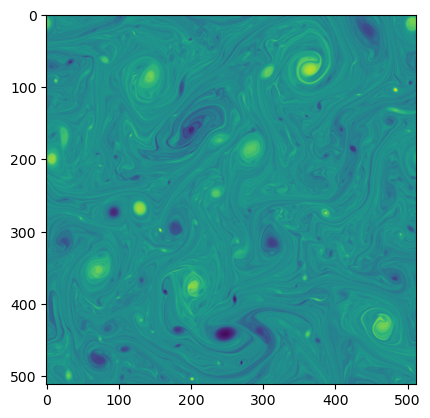

In [8]:
# Choose target image frame to synthesize 
target_index = 0
target_image = image[target_index]
plt.imshow(target_image)

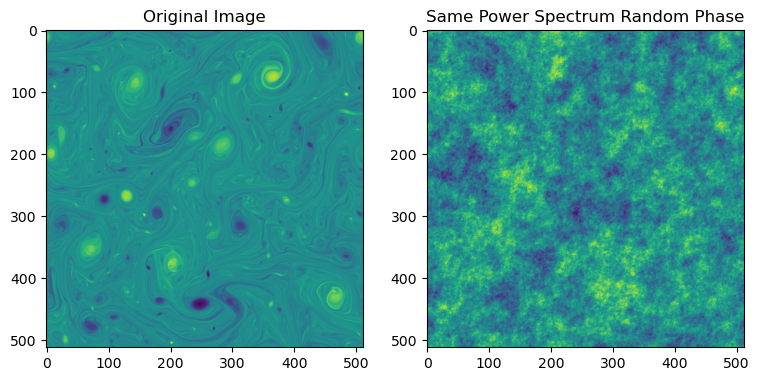

In [ ]:
# 1. Power Spectrum Synthesis

# Fourier Transform of the target
fft_data = np.fft.fft2(target_image)

# Extract the Magnitude
magnitude = np.abs(fft_data)

# Generate Random Phases
random_phase = np.random.uniform(-np.pi, np.pi, magnitude.shape)

# Recombine Magnitude and Random Phase
new_fft_data = magnitude * np.exp(1j * random_phase)

# Inverse FFT to get back to the spatial domain
synthesized_image_power = np.fft.ifft2(new_fft_data).real

# Plot
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(target_image)
axes[0].set_title("Original Image")
axes[1].imshow(synthesized_image_power)
axes[1].set_title("Same Power Spectrum Random Phase")
plt.show()


 0.0505 s
Step 0000 | loss: 6.5706e+28 | mean: 0.0000e+00 | bound: 6.5706e+28 | L1: 6.4996e+04 | bi: 6.7647e+07
Step 0100 | loss: 9.3402e+25 | mean: 1.5378e+02 | bound: 9.3402e+25 | L1: 2.2983e+04 | bi: 5.6881e+04
Step 0000 | loss: 7.2786e+25 | mean: 1.7432e+02 | bound: 7.2786e+25 | L1: 2.1930e+04 | bi: 2.1874e+04
Step 0100 | loss: 1.3566e+24 | mean: 4.0468e+02 | bound: 1.3566e+24 | L1: 1.6135e+04 | bi: 1.8659e+04
Step 0000 | loss: 7.6831e+23 | mean: 4.6236e+02 | bound: 7.6831e+23 | L1: 1.5152e+04 | bi: 1.0769e+04
Step 0000 | loss: 1.4320e+22 | mean: 7.0032e+02 | bound: 1.4320e+22 | L1: 1.2354e+04 | bi: 1.2053e+04
Step 0000 | loss: 5.7979e+20 | mean: 8.6601e+02 | bound: 5.7979e+20 | L1: 1.1452e+04 | bi: 8.5565e+03
Step 0000 | loss: 6.0576e+19 | mean: 9.7927e+02 | bound: 6.0576e+19 | L1: 1.0919e+04 | bi: 5.2803e+03


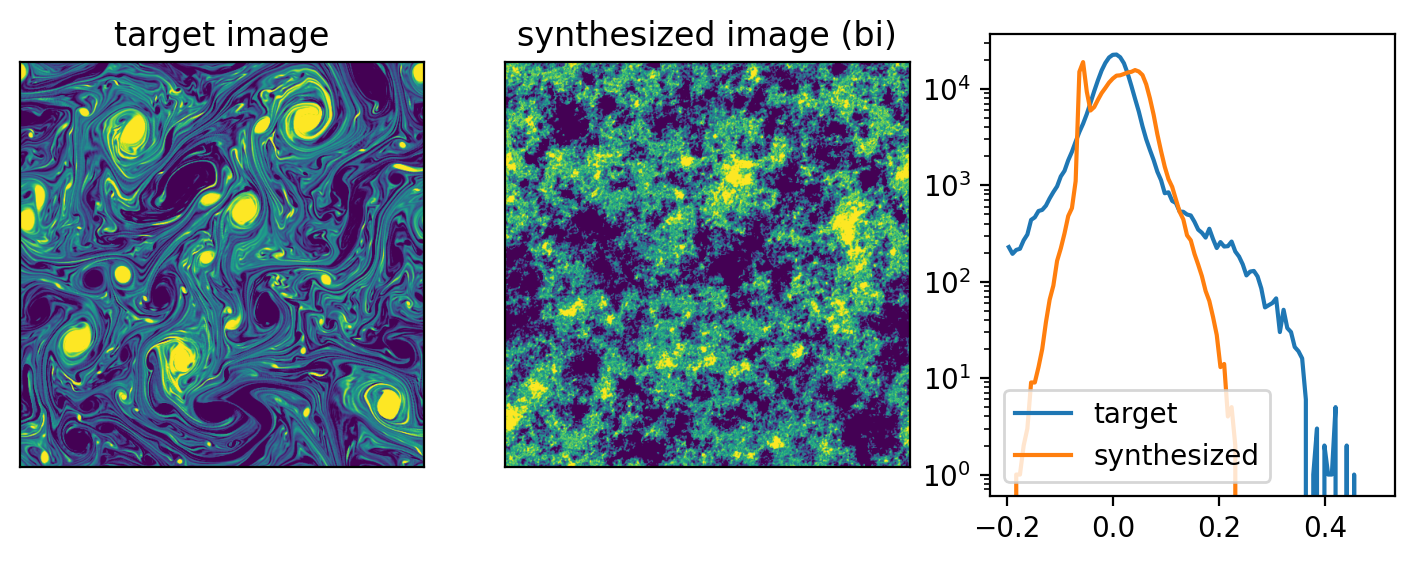

0.05328313250671461 0.046394452


In [ ]:
# 2. Bispectrum Synthesis (Following Cheng Code)

M, N = target_image.shape
J = 8
L = 8

bin_edges = np.linspace(150/(360/3.5), M/2*1.4, 7) # bins in unit of pixel in Fourier space

# Setup the Bispectrum Calculator
bispectrum_calculator = ST.Bispectrum_Calculator(bin_edges, M, N, device='cpu')
image_torch = torch.from_numpy(target_image)
torch.set_num_threads(1) 
start = time.time()
B = bispectrum_calculator.forward(image_torch)
print('% .4f s' % (time.time() - start))

# synthesis
for random_seed in [987]:
    synthesised_image = image_synthesis(
        target_image, 
        J=J, 
        L=L, 
        num_pixel=M,
        learnable_param_list = [
            (100*2, 5e-3), (100*2, 1e-3), (100*1, 1e-3),
            (100*1, 5e-4), (100*1, 2e-4), (100*1, 1e-4),
        ],
        coef = 'bi',
        random_seed = random_seed,
        low_bound = -0.015,#-0.010,
    )
    
    synthesised_image_bi = synthesised_image[0]
    plt.figure(figsize=(12,3),dpi=200)
    plt.subplot(141)
    plt.imshow(target_image, vmin=-0.04, vmax=0.10, )
    plt.title('target image')
    plt.xticks([]); plt.yticks([])

    plt.subplot(142)
    plt.imshow(synthesised_image_bi, 
               vmin=-0.04, vmax=0.10, )
    plt.title('synthesized image (bi)')
    plt.xticks([]); plt.yticks([])
    
    plt.subplot(143)
    y, x = np.histogram(target_image,  100, (-0.2,0.5))
    plt.plot((x[1:]+x[:-1])/2, y, label='target')
    y, x = np.histogram(synthesised_image_bi,
                        100, (-0.2,0.5))
    plt.plot((x[1:]+x[:-1])/2, y, label='synthesized')
    plt.legend()
    plt.yscale('log')
    plt.show()
    print(image.std(),  synthesised_image_bi.std())

In [ ]:
# 3. ST Synthesis (Following Cheng Code)

M, N = target_image.shape
J = 8
L = 8

# Setup the ST Calculator
filters_set = ST.FiltersSet(M=M, N=N, J=J, L=L).generate_morlet(
    if_save=False, save_dir=None, precision='single'
)
ST_calculator = ST.ST_2D(filters_set, J, L, device='cpu')
image_torch = torch.from_numpy(target_image)[None,:,:]
torch.set_num_threads(2) 
start = time.time()
S = ST_calculator.forward(image_torch, J, L)[0]
print('% .4f s' % (time.time() - start))

# synthesis
for random_seed in [987]:
    synthesised_image = image_synthesis(
        target_image, 
        J=J, 
        L=L, 
        num_pixel=M,
        learnable_param_list = [
            (100*2, 5e-3), (100*2, 1e-3), (100*1, 1e-3),
            (100*1, 5e-4), (100*1, 2e-4), (100*1, 1e-4),
        ],
        coef = 'ST',
        random_seed = random_seed,
        low_bound = -0.015,#-0.010,
    )
    
    synthesised_image_st = synthesised_image[0]
    plt.figure(figsize=(12,3),dpi=200)
    plt.subplot(141)
    plt.imshow(target_image, vmin=-0.04, vmax=0.10, )
    plt.title('target image')
    plt.xticks([]); plt.yticks([])

    plt.subplot(142)
    plt.imshow(synthesised_image_st, 
               vmin=-0.04, vmax=0.10, )
    plt.title('synthesized image (ST)')
    plt.xticks([]); plt.yticks([])
    
    plt.subplot(143)
    y, x = np.histogram(target_image,  100, (-0.2,0.5))
    plt.plot((x[1:]+x[:-1])/2, y, label='target')
    y, x = np.histogram(synthesised_image_st,
                        100, (-0.2,0.5))
    plt.plot((x[1:]+x[:-1])/2, y, label='synthesized')
    plt.legend()
    plt.yscale('log')
    plt.show()
    print(image.std(),  synthesised_image_st.std())

/Users/jackskinner/miniforge3/envs/d3/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


 0.5797 s
Step 0000 | loss: 6.5706e+28 | mean: 0.0000e+00 | bound: 6.5706e+28 | L1: 6.4996e+04 | ST: 2.6577e+05
Step 0100 | loss: 9.3402e+25 | mean: 8.8761e+01 | bound: 9.3402e+25 | L1: 9.8116e+01 | ST: 5.1907e+03
Step 0000 | loss: 7.2786e+25 | mean: 1.0813e+02 | bound: 7.2786e+25 | L1: 2.0966e+01 | ST: 2.3918e+03
